In [1]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================================
# Create Synthetic Dataset
# ============================================================

np.random.seed(42)

n = 1000

area = np.random.randint(600, 4500, n)

bedrooms = np.random.randint(1, 6, n)

bathrooms = bedrooms + np.random.randint(0,2,n)

house_age = np.random.randint(1,40,n)

distance_city = np.random.randint(1,30,n)

parking = np.random.randint(0,4,n)

quality_score = np.random.randint(1,11,n)

crime_rate = np.random.uniform(1,10,n)

school_rating = np.random.randint(1,11,n)

In [3]:
price = (
    area * 180
    + bedrooms * 300000
    + bathrooms * 250000
    + quality_score * 400000
    - house_age * 12000
    - distance_city * 15000
    - crime_rate * 80000
    + school_rating * 100000
    + parking * 200000
    + np.random.normal(0,300000,n)
)

In [4]:
df = pd.DataFrame({

    "Area":area,

    "Bedrooms":bedrooms,

    "Bathrooms":bathrooms,

    "HouseAge":house_age,

    "DistanceCity":distance_city,

    "Parking":parking,

    "Quality":quality_score,

    "CrimeRate":crime_rate,

    "SchoolRating":school_rating,

    "Price":price

})

df.head()

,Area,Bedrooms,Bathrooms,HouseAge,DistanceCity,Parking,Quality,CrimeRate,SchoolRating,Price
0,3774,1,1,25,2,3,2,1.203081,1,2.136883e+06
1,4107,5,6,10,16,0,8,8.754984,8,7.071476e+06
2,1460,4,5,21,9,0,3,6.194054,5,2.908588e+06
3,1894,1,1,36,9,0,7,9.015926,1,2.217070e+06
4,1730,5,6,12,6,0,1,6.372507,4,3.499320e+06


In [5]:
df = pd.DataFrame({

    "Area":area,

    "Bedrooms":bedrooms,

    "Bathrooms":bathrooms,

    "HouseAge":house_age,

    "DistanceCity":distance_city,

    "Parking":parking,

    "Quality":quality_score,

    "CrimeRate":crime_rate,

    "SchoolRating":school_rating,

    "Price":price

})

df.head()

,Area,Bedrooms,Bathrooms,HouseAge,DistanceCity,Parking,Quality,CrimeRate,SchoolRating,Price
0,3774,1,1,25,2,3,2,1.203081,1,2.136883e+06
1,4107,5,6,10,16,0,8,8.754984,8,7.071476e+06
2,1460,4,5,21,9,0,3,6.194054,5,2.908588e+06
3,1894,1,1,36,9,0,7,9.015926,1,2.217070e+06
4,1730,5,6,12,6,0,1,6.372507,4,3.499320e+06


In [6]:
df.shape

(1000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Area          1000 non-null   int32  
 1   Bedrooms      1000 non-null   int32  
 2   Bathrooms     1000 non-null   int32  
 3   HouseAge      1000 non-null   int32  
 4   DistanceCity  1000 non-null   int32  
 5   Parking       1000 non-null   int32  
 6   Quality       1000 non-null   int32  
 7   CrimeRate     1000 non-null   float64
 8   SchoolRating  1000 non-null   int32  
 9   Price         1000 non-null   float64
dtypes: float64(2), int32(8)
memory usage: 47.0 KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,1000.0,2.577128e+03,1.109862e+03,601.000000,1.628000e+03,2.519000e+03,3.569000e+03,4.498000e+03
Bedrooms,1000.0,2.961000e+00,1.422499e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Bathrooms,1000.0,3.472000e+00,1.511788e+00,1.000000,2.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00
HouseAge,1000.0,2.043300e+01,1.107936e+01,1.000000,1.100000e+01,2.100000e+01,3.000000e+01,3.900000e+01
DistanceCity,1000.0,1.531100e+01,8.506153e+00,1.000000,8.000000e+00,1.600000e+01,2.300000e+01,2.900000e+01
Parking,1000.0,1.517000e+00,1.119359e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00
Quality,1000.0,5.616000e+00,2.833827e+00,1.000000,3.000000e+00,6.000000e+00,8.000000e+00,1.000000e+01
CrimeRate,1000.0,5.489166e+00,2.590255e+00,1.002043,3.297001e+00,5.350286e+00,7.766244e+00,9.989136e+00
SchoolRating,1000.0,5.505000e+00,2.905239e+00,1.000000,3.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01
Price,1000.0,4.386287e+06,1.506569e+06,398938.973582,3.300619e+06,4.379159e+06,5.405031e+06,8.138327e+06


# Exploratory Data Analysis

Now we begin EDA.

Objectives

- Understand distributions
- Detect anomalies
- Understand relationships
- Prepare for regression

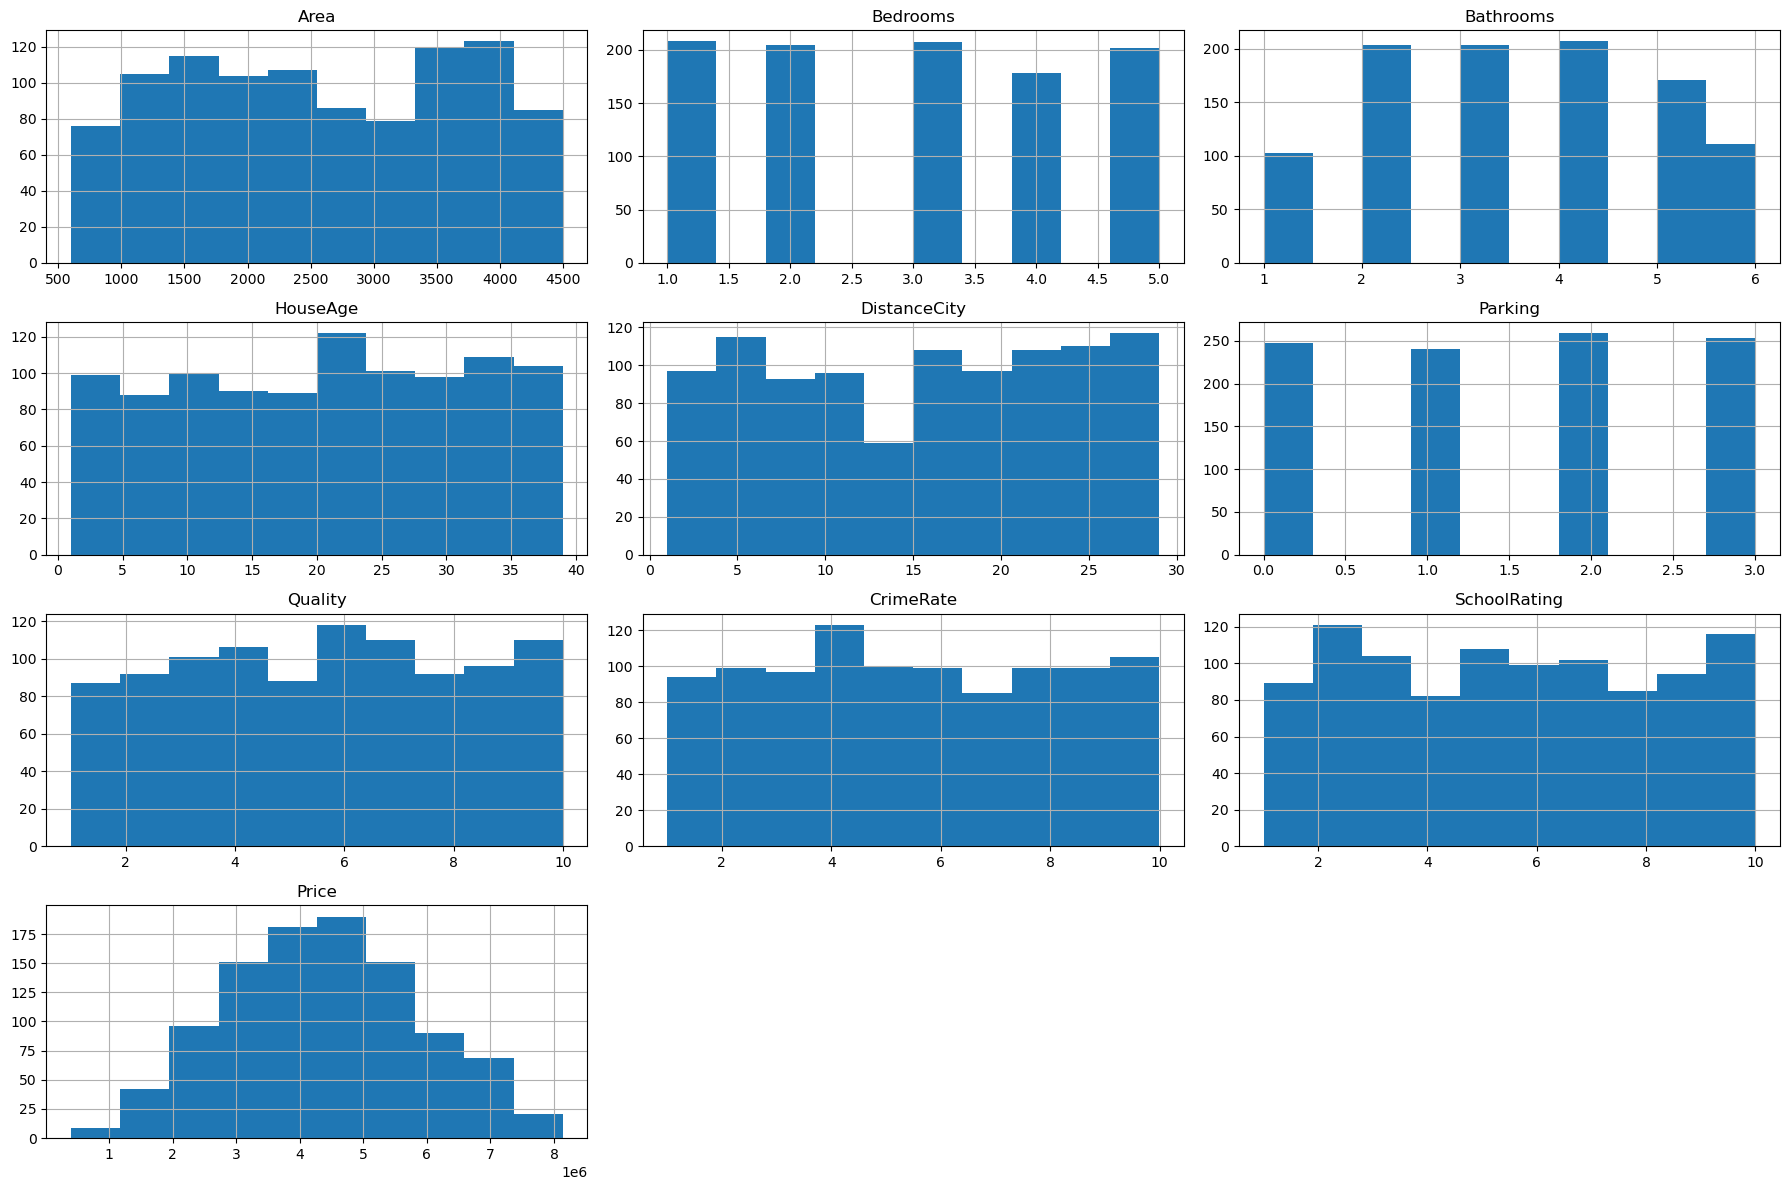

In [9]:
df.hist(figsize=(18,12))

plt.tight_layout()

plt.show()

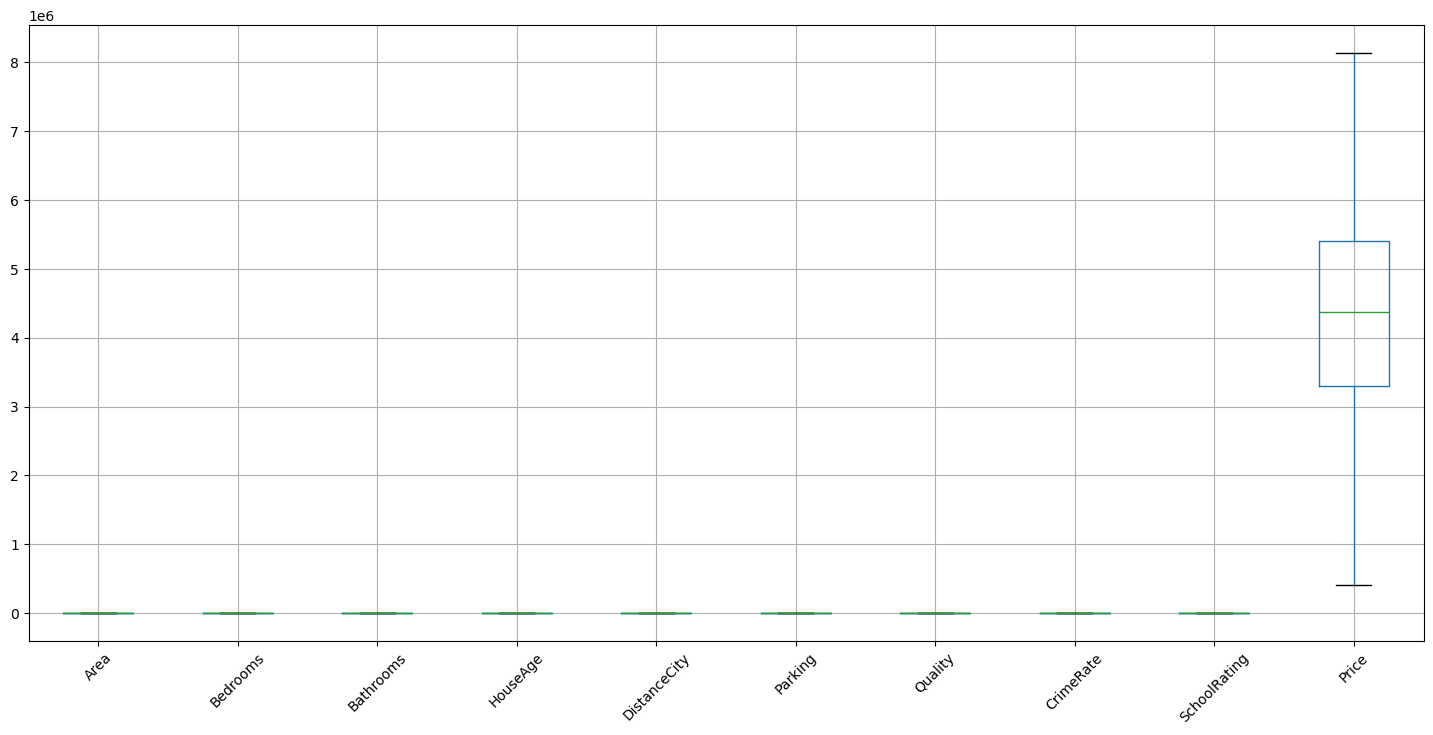

In [10]:
df.boxplot(figsize=(18,8))

plt.xticks(rotation=45)

plt.show()

In [11]:
correlation = df.corr()

correlation

,Area,Bedrooms,Bathrooms,HouseAge,DistanceCity,Parking,Quality,CrimeRate,SchoolRating,Price
Area,1.000000,-0.071335,-0.069642,0.000638,-0.020262,-0.023529,-0.035688,-0.006522,0.041065,0.094162
Bedrooms,-0.071335,1.000000,0.943698,0.001835,-0.048550,0.019591,0.012422,0.016203,-0.009036,0.535507
Bathrooms,-0.069642,0.943698,1.000000,0.004519,-0.066460,0.020689,0.009404,0.015792,-0.001222,0.536590
HouseAge,0.000638,0.001835,0.004519,1.000000,0.027333,-0.000150,0.026407,0.013305,0.045943,-0.068466
DistanceCity,-0.020262,-0.048550,-0.066460,0.027333,1.000000,0.015687,-0.050105,-0.048393,0.016200,-0.137695
Parking,-0.023529,0.019591,0.020689,-0.000150,0.015687,1.000000,-0.024763,0.025768,-0.007414,0.128663
Quality,-0.035688,0.012422,0.009404,0.026407,-0.050105,-0.024763,1.000000,-0.022279,-0.033324,0.749701
CrimeRate,-0.006522,0.016203,0.015792,0.013305,-0.048393,0.025768,-0.022279,1.000000,0.027451,-0.136065
SchoolRating,0.041065,-0.009036,-0.001222,0.045943,0.016200,-0.007414,-0.033324,0.027451,1.000000,0.152144
Price,0.094162,0.535507,0.536590,-0.068466,-0.137695,0.128663,0.749701,-0.136065,0.152144,1.000000


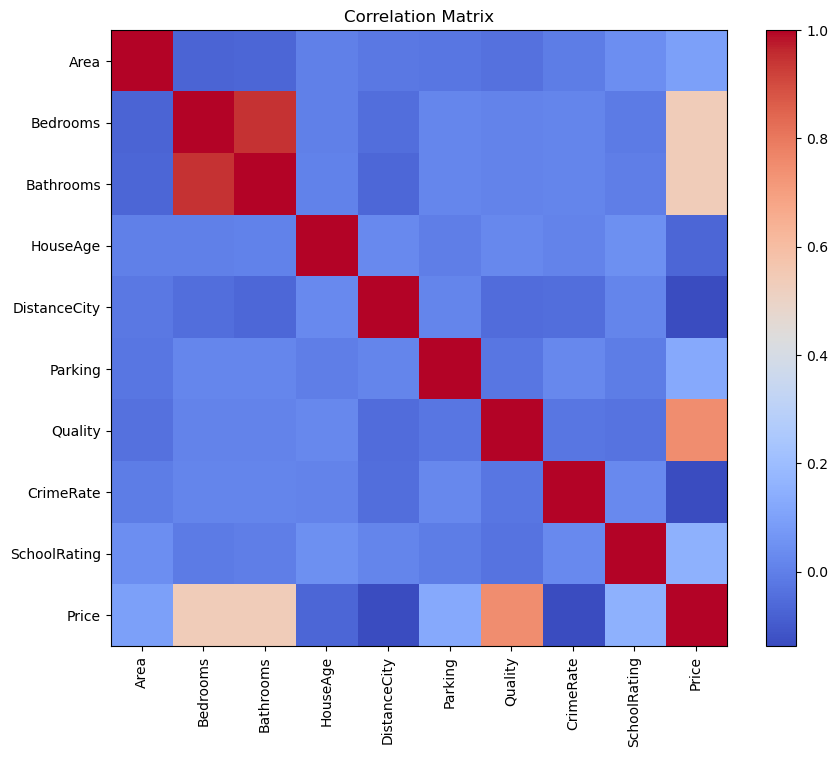

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

cax = ax.imshow(correlation, cmap="coolwarm")

ax.set_xticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=90)

ax.set_yticks(range(len(correlation.columns)))
ax.set_yticklabels(correlation.columns)

fig.colorbar(cax)

plt.title("Correlation Matrix")

plt.show()

In [13]:
# ============================================================
# Introduce Missing Values (for practice)
# ============================================================

np.random.seed(42)

# Add missing values to Area
df.loc[np.random.choice(df.index, 25, replace=False), "Area"] = np.nan

# Add missing values to Quality
df.loc[np.random.choice(df.index, 20, replace=False), "Quality"] = np.nan

# Add missing values to SchoolRating
df.loc[np.random.choice(df.index, 15, replace=False), "SchoolRating"] = np.nan

print("Missing values introduced successfully.")

Missing values introduced successfully.


In [14]:
# Check Missing Values

df.isnull().sum()

Area            25
Bedrooms         0
Bathrooms        0
HouseAge         0
DistanceCity     0
Parking          0
Quality         20
CrimeRate        0
SchoolRating    15
Price            0
dtype: int64

In [15]:
# Percentage of Missing Values

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

Area            2.5
Quality         2.0
SchoolRating    1.5
Bedrooms        0.0
Bathrooms       0.0
HouseAge        0.0
Parking         0.0
DistanceCity    0.0
CrimeRate       0.0
Price           0.0
dtype: float64

## Handling Missing Values

There are several ways to handle missing values:

1. Drop rows
2. Drop columns
3. Fill using Mean
4. Fill using Median
5. Fill using Mode
6. Predict missing values using ML

Since our missing values are numerical and only a small percentage,
we'll use the median.

In [16]:
# Fill Missing Values

df["Area"].fillna(df["Area"].median(), inplace=True)

df["Quality"].fillna(df["Quality"].median(), inplace=True)

df["SchoolRating"].fillna(df["SchoolRating"].median(), inplace=True)

In [17]:
# Verify Missing Values

df.isnull().sum()

Area            0
Bedrooms        0
Bathrooms       0
HouseAge        0
DistanceCity    0
Parking         0
Quality         0
CrimeRate       0
SchoolRating    0
Price           0
dtype: int64

In [18]:
# Create Duplicate Rows (for practice)

duplicate_rows = df.sample(10, random_state=42)

df = pd.concat([df, duplicate_rows], ignore_index=True)

print(df.shape)

(1010, 10)


In [19]:
# Count Duplicate Rows

df.duplicated().sum()

np.int64(10)

In [20]:
# Remove Duplicate Rows

df.drop_duplicates(inplace=True)

df.reset_index(drop=True, inplace=True)

print(df.shape)

(1000, 10)


# Correlation Analysis

Correlation measures the strength of the relationship
between two numerical variables.

Correlation values range from:

+1  → Perfect Positive Correlation

0   → No Correlation

-1  → Perfect Negative Correlation

Why is this important?

• Understand relationships
• Select useful features
• Detect multicollinearity

In [21]:
# Correlation Matrix

corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Area,Bedrooms,Bathrooms,HouseAge,DistanceCity,Parking,Quality,CrimeRate,SchoolRating,Price
Area,1.000000,-0.071227,-0.068112,0.002502,-0.022205,-0.020958,-0.031878,-0.010792,0.038229,0.096800
Bedrooms,-0.071227,1.000000,0.943698,0.001835,-0.048550,0.019591,0.013468,0.016203,-0.008615,0.535507
Bathrooms,-0.068112,0.943698,1.000000,0.004519,-0.066460,0.020689,0.008549,0.015792,-0.001589,0.536590
HouseAge,0.002502,0.001835,0.004519,1.000000,0.027333,-0.000150,0.028866,0.013305,0.046013,-0.068466
DistanceCity,-0.022205,-0.048550,-0.066460,0.027333,1.000000,0.015687,-0.062169,-0.048393,0.011179,-0.137695
Parking,-0.020958,0.019591,0.020689,-0.000150,0.015687,1.000000,-0.029796,0.025768,-0.004183,0.128663
Quality,-0.031878,0.013468,0.008549,0.028866,-0.062169,-0.029796,1.000000,-0.030669,-0.035963,0.739661
CrimeRate,-0.010792,0.016203,0.015792,0.013305,-0.048393,0.025768,-0.030669,1.000000,0.034000,-0.136065
SchoolRating,0.038229,-0.008615,-0.001589,0.046013,0.011179,-0.004183,-0.035963,0.034000,1.000000,0.151306
Price,0.096800,0.535507,0.536590,-0.068466,-0.137695,0.128663,0.739661,-0.136065,0.151306,1.000000


In [22]:
# Correlation with Target Variable

corr_target = corr_matrix["Price"].sort_values(ascending=False)

corr_target

Price           1.000000
Quality         0.739661
Bathrooms       0.536590
Bedrooms        0.535507
SchoolRating    0.151306
Parking         0.128663
Area            0.096800
HouseAge       -0.068466
CrimeRate      -0.136065
DistanceCity   -0.137695
Name: Price, dtype: float64

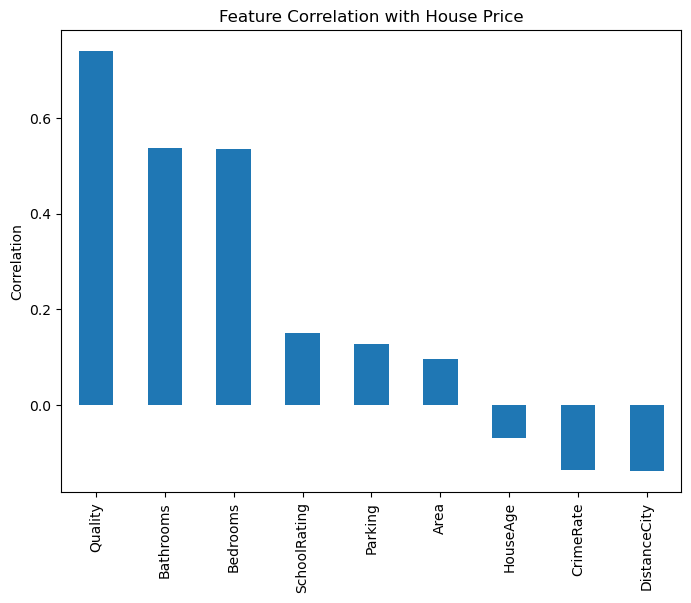

In [23]:
plt.figure(figsize=(8,6))

corr_target.drop("Price").plot(kind="bar")

plt.title("Feature Correlation with House Price")

plt.ylabel("Correlation")

plt.show()

# Multicollinearity

Multicollinearity occurs when two or more independent variables
are highly correlated with each other.

Problems

- Unstable coefficients
- High variance
- Difficult interpretation
- Poor generalization

We'll detect it using VIF.

In [24]:
# ============================================================
# Prepare Features
# ============================================================

X = df.drop("Price", axis=1)

y = df["Price"]

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
2,Bathrooms,55.567322
1,Bedrooms,48.798146
0,Area,5.285004
7,CrimeRate,4.772564
6,Quality,4.297874
8,SchoolRating,4.253320
3,HouseAge,4.099783
4,DistanceCity,3.705508
5,Parking,2.696724


# Train-Test Split

Why?

We train on one dataset and evaluate on unseen data.

This helps us estimate how well the model generalizes.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (800, 9)
Testing Samples : (200, 9)


# Feature Scaling

Different features have different units.

Area = 3000

Parking = 2

Without scaling,

Area dominates the model.

We'll standardize the data.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Simple Linear Regression

Simple Linear Regression uses one independent variable to predict the target.

We'll use:

Area → Price

In [28]:
# Use only Area

X_simple = df[["Area"]]

y_simple = df["Price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

In [29]:
simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

LinearRegression()

In [30]:
print("Intercept:", simple_model.intercept_)

print("Coefficient:", simple_model.coef_[0])

Intercept: 4012953.832491315
Coefficient: 125.80140202113785


In [31]:
y_pred_simple = simple_model.predict(X_test_s)

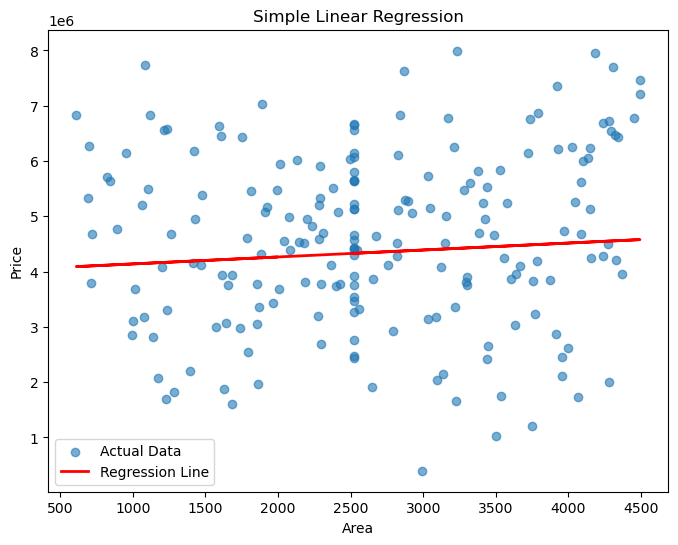

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(X_test_s, y_test_s, alpha=0.6, label="Actual Data")

plt.plot(
    X_test_s,
    y_pred_simple,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

In [33]:
mae = mean_absolute_error(y_test_s, y_pred_simple)

mse = mean_squared_error(y_test_s, y_pred_simple)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_s, y_pred_simple)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1282624.99
MSE  : 2454754974218.07
RMSE : 1566765.77
R²   : -0.0153


# Multiple Linear Regression

Simple Linear Regression uses only one independent variable.

In reality, house prices depend on many factors:

- Area
- Bedrooms
- Bathrooms
- House Age
- Parking
- Quality
- Crime Rate
- School Rating
- Distance from City

Multiple Linear Regression models the relationship between all these features and the target simultaneously.

In [34]:
# ============================================================
# Multiple Linear Regression
# ============================================================

multiple_model = LinearRegression()

multiple_model.fit(X_train_scaled, y_train)

LinearRegression()

In [35]:
# Model Coefficients

coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": multiple_model.coef_

})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
6,Quality,1.114766e+06
2,Bathrooms,4.524635e+05
1,Bedrooms,3.676463e+05
8,SchoolRating,2.795894e+05
0,Area,2.256470e+05
5,Parking,2.244809e+05
4,DistanceCity,-1.013197e+05
3,HouseAge,-1.486117e+05
7,CrimeRate,-1.916484e+05


In [36]:
print("Intercept")

print(multiple_model.intercept_)

Intercept
4335090.494863545


In [37]:
# Predictions

y_pred = multiple_model.predict(X_test_scaled)

In [38]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 258911.26059396952
MSE : 138301510119.79047
RMSE : 371889.1099774104
R2 Score : 0.9427974761827163


In [39]:
results = pd.DataFrame({

    "Actual Price": y_test,

    "Predicted Price": y_pred

})

results.head(10)

,Actual Price,Predicted Price
521,6.568125e+06,6.732220e+06
737,3.539981e+06,3.693645e+06
740,3.917349e+06,3.811494e+06
660,6.650411e+06,5.985529e+06
411,5.132632e+06,5.635335e+06
678,3.753867e+06,3.949845e+06
626,2.478041e+06,2.596881e+06
513,5.809961e+06,5.858780e+06
859,5.637434e+06,5.758692e+06
136,6.137538e+06,5.853636e+06


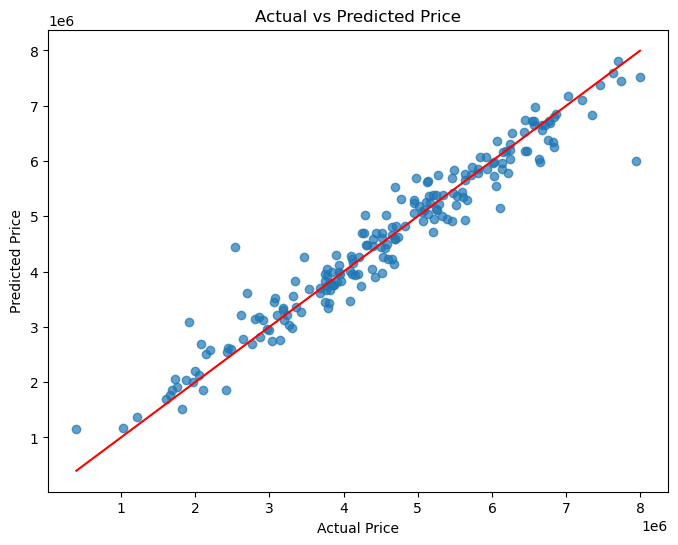

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.7

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.show()

# Residual Analysis

Residual = Actual Price - Predicted Price

Residuals help us understand whether the model satisfies
the assumptions of Linear Regression.

A good model should have residuals that are:

- Randomly scattered
- Normally distributed
- Mean close to zero
- Constant variance

In [41]:
# Calculate Residuals

residuals = y_test - y_pred

In [42]:
results["Residual"] = residuals

results.head()

,Actual Price,Predicted Price,Residual
521,6.568125e+06,6.732220e+06,-164095.354760
737,3.539981e+06,3.693645e+06,-153664.618749
740,3.917349e+06,3.811494e+06,105854.598301
660,6.650411e+06,5.985529e+06,664881.829575
411,5.132632e+06,5.635335e+06,-502702.940055


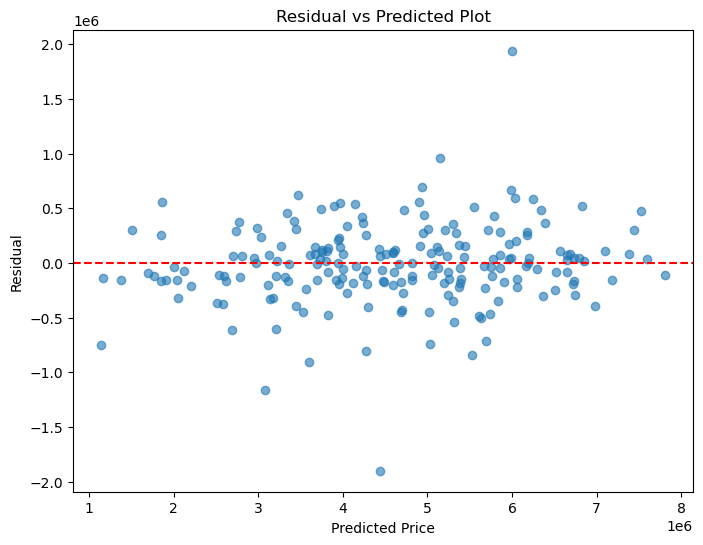

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_pred,

    residuals,

    alpha=0.6

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual vs Predicted Plot")

plt.show()

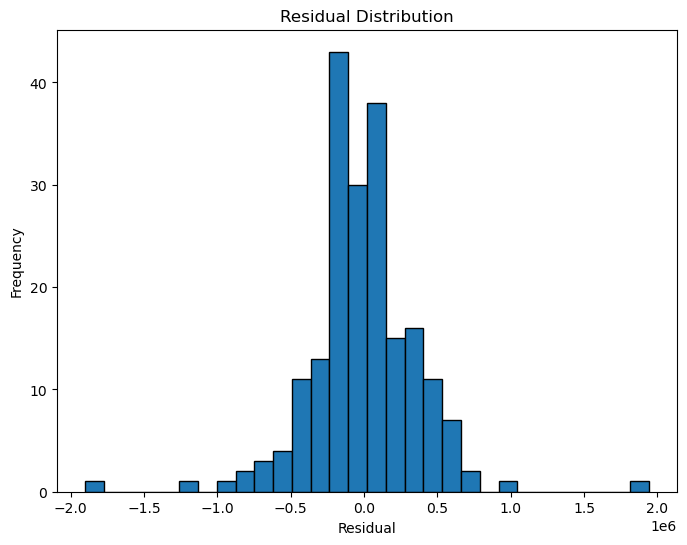

In [44]:
plt.figure(figsize=(8,6))

plt.hist(

    residuals,

    bins=30,

    edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

In [45]:
print("Mean Residual")

print(np.mean(residuals))

Mean Residual
-9507.898632322922


# Polynomial Regression

Linear Regression assumes a straight-line relationship between
the features and the target.

However, many real-world relationships are nonlinear.

Example:

House Price vs Area

Small House      → Cheap
Medium House     → Moderate
Luxury House     → Price increases much faster

Polynomial Regression captures these curved relationships by
creating higher-order features.

In [46]:
# ============================================================
# Polynomial Features
# ============================================================

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)

X_test_poly = poly.transform(X_test_scaled)

print("Original Features :", X_train.shape[1])

print("Polynomial Features :", X_train_poly.shape[1])

Original Features : 9
Polynomial Features : 54


In [47]:
poly_model = LinearRegression()

poly_model.fit(

    X_train_poly,

    y_train

)

LinearRegression()

In [48]:
y_pred_poly = poly_model.predict(X_test_poly)

In [49]:
print("Polynomial Regression Performance\n")

print("MAE :", mean_absolute_error(y_test, y_pred_poly))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

print("R² :", r2_score(y_test, y_pred_poly))

Polynomial Regression Performance

MAE : 265372.7409313071
RMSE : 375870.23185064073
R² : 0.9415661996886524


# Overfitting vs Underfitting

A good model should generalize well.

Underfitting

Model is too simple.

Training Error → High

Testing Error → High

----------------------------

Overfitting

Model memorizes training data.

Training Error → Very Low

Testing Error → High

----------------------------

Good Model

Training Error → Low

Testing Error → Low

In [50]:
train_prediction = poly_model.predict(X_train_poly)

test_prediction = poly_model.predict(X_test_poly)

print("Training R²")

print(r2_score(y_train, train_prediction))

print()

print("Testing R²")

print(r2_score(y_test, test_prediction))

Training R²
0.9429248498451044

Testing R²
0.9415661996886524


# Ridge Regression

Problem

Linear Regression may produce very large coefficients.

Large coefficients often cause

- Overfitting
- High variance
- Unstable predictions

Ridge Regression adds an L2 penalty
to shrink coefficients.

In [51]:
ridge = Ridge(alpha=1.0)

ridge.fit(

    X_train_scaled,

    y_train

)

ridge_prediction = ridge.predict(X_test_scaled)

In [52]:
print("Ridge Regression")

print("MAE :", mean_absolute_error(y_test, ridge_prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_prediction)))

print("R² :", r2_score(y_test, ridge_prediction))

Ridge Regression
MAE : 259129.78835406058
RMSE : 372086.5866789051
R² : 0.9427367098703726


# Lasso Regression

Lasso adds an L1 penalty.

Unlike Ridge,

Lasso can shrink some coefficients
exactly to zero.

This means it automatically performs
feature selection.

In [53]:
lasso = Lasso(alpha=1000)

lasso.fit(

    X_train_scaled,

    y_train

)

lasso_prediction = lasso.predict(X_test_scaled)

In [54]:
print("Lasso Regression")

print("MAE :", mean_absolute_error(y_test, lasso_prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lasso_prediction)))

print("R² :", r2_score(y_test, lasso_prediction))

Lasso Regression
MAE : 259233.03364011899
RMSE : 372104.37994754966
R² : 0.942731233051249


In [55]:
lasso_coef = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": lasso.coef_

})

lasso_coef

,Feature,Coefficient
0,Area,2.245907e+05
1,Bedrooms,3.680388e+05
2,Bathrooms,4.510971e+05
3,HouseAge,-1.474941e+05
4,DistanceCity,-1.003790e+05
5,Parking,2.234032e+05
6,Quality,1.113692e+06
7,CrimeRate,-1.906670e+05
8,SchoolRating,2.784668e+05


# Elastic Net

Elastic Net combines both

- Ridge Regression
- Lasso Regression

It is useful when

- Features are correlated
- Feature selection is required

In [56]:
elastic = ElasticNet(

    alpha=0.5,

    l1_ratio=0.5

)

elastic.fit(

    X_train_scaled,

    y_train

)

elastic_prediction = elastic.predict(X_test_scaled)

In [57]:
print("Elastic Net")

print("MAE :", mean_absolute_error(y_test, elastic_prediction))

print("RMSE :", np.sqrt(mean_squared_error(y_test, elastic_prediction)))

print("R² :", r2_score(y_test, elastic_prediction))

Elastic Net
MAE : 364660.523749701
RMSE : 487266.29843908246
R² : 0.9017978451409693


In [58]:
comparison = pd.DataFrame({

    "Model":[

        "Simple LR",

        "Multiple LR",

        "Polynomial",

        "Ridge",

        "Lasso",

        "ElasticNet"

    ],

    "R2":[

        r2_score(y_test_s,y_pred_simple),

        r2_score(y_test,y_pred),

        r2_score(y_test,y_pred_poly),

        r2_score(y_test,ridge_prediction),

        r2_score(y_test,lasso_prediction),

        r2_score(y_test,elastic_prediction)

    ]

})

comparison.sort_values(

    by="R2",

    ascending=False

)

,Model,R2
1,Multiple LR,0.942797
3,Ridge,0.942737
4,Lasso,0.942731
2,Polynomial,0.941566
5,ElasticNet,0.901798
0,Simple LR,-0.015305


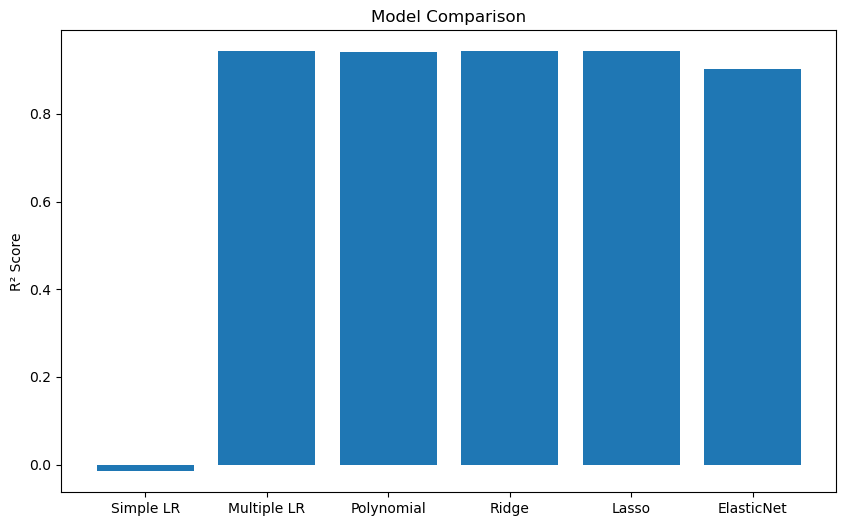

In [59]:
plt.figure(figsize=(10,6))

plt.bar(

    comparison["Model"],

    comparison["R2"]

)

plt.ylabel("R² Score")

plt.title("Model Comparison")

plt.show()

# Cross Validation

Problem with Train-Test Split

The performance of a model depends on how the data is split.

One split may give:

R² = 0.95

Another split may give:

R² = 0.88

Cross Validation solves this problem.

It trains and evaluates the model multiple times on different splits.

Advantages

✔ Better estimate of model performance

✔ Less biased

✔ More reliable

In [60]:
# ============================================================
# Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score

linear_cv = cross_val_score(

    LinearRegression(),

    X,

    y,

    cv=5,

    scoring="r2"

)

print(linear_cv)

[0.93973468 0.94473781 0.9549524  0.92402503 0.93249243]


In [61]:
print("Average R²")

print(np.mean(linear_cv))

print()

print("Standard Deviation")

print(np.std(linear_cv))

Average R²
0.9391884701169311

Standard Deviation
0.010529594799473577


# Hyperparameter Tuning

Hyperparameters are values chosen before training.

Example

Ridge(alpha=?)

What is the best alpha?

Instead of guessing,

we use Grid Search.

In [62]:
# ============================================================
# Ridge Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

ridge = Ridge()

parameters = {

    "alpha":[

        0.01,

        0.1,

        1,

        10,

        100,

        1000

    ]

}

In [63]:
grid = GridSearchCV(

    estimator=ridge,

    param_grid=parameters,

    cv=5,

    scoring="r2"

)

grid.fit(

    X_train_scaled,

    y_train

)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100, 1000]}, scoring='r2')

In [64]:
print("Best Parameters")

print(grid.best_params_)

print()

print("Best Score")

print(grid.best_score_)

Best Parameters
{'alpha': 1}

Best Score
0.9382787232637775


In [65]:
best_ridge = grid.best_estimator_

best_prediction = best_ridge.predict(X_test_scaled)

In [66]:
print("Optimized Ridge")

print("R²")

print(r2_score(

    y_test,

    best_prediction

))

Optimized Ridge
R²
0.9427367098703726


# Feature Importance

Regression coefficients indicate

- Positive impact
- Negative impact

The larger the absolute coefficient,

the greater the influence on predictions.

In [67]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":multiple_model.coef_

})

importance["Absolute"] = importance["Coefficient"].abs()

importance.sort_values(

    by="Absolute",

    ascending=False,

    inplace=True

)

importance

,Feature,Coefficient,Absolute
6,Quality,1.114766e+06,1.114766e+06
2,Bathrooms,4.524635e+05,4.524635e+05
1,Bedrooms,3.676463e+05,3.676463e+05
8,SchoolRating,2.795894e+05,2.795894e+05
0,Area,2.256470e+05,2.256470e+05
5,Parking,2.244809e+05,2.244809e+05
7,CrimeRate,-1.916484e+05,1.916484e+05
3,HouseAge,-1.486117e+05,1.486117e+05
4,DistanceCity,-1.013197e+05,1.013197e+05


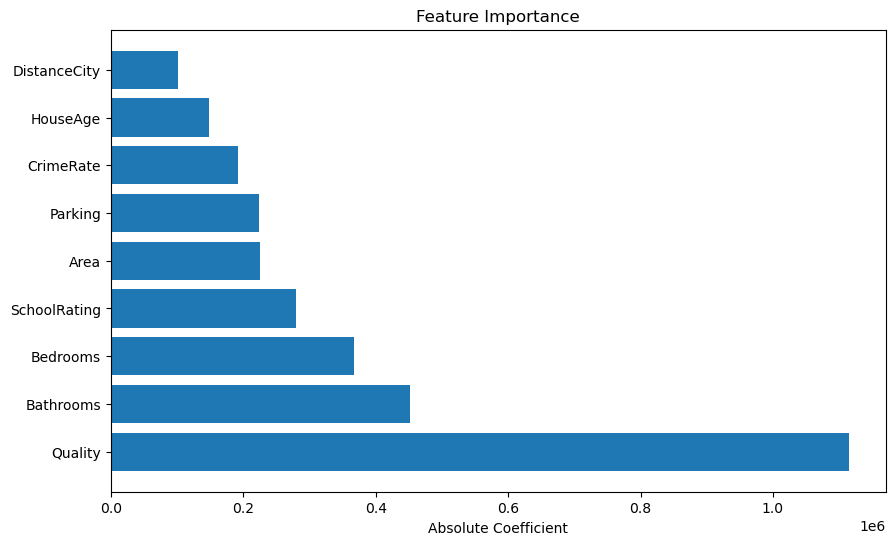

In [68]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Absolute"]

)

plt.title("Feature Importance")

plt.xlabel("Absolute Coefficient")

plt.show()

# Save Model

Training takes time.

Instead of training every time,

we save the model.

In [69]:
import joblib

joblib.dump(

    best_ridge,

    "HousePriceModel.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [70]:
joblib.dump(

    scaler,

    "Scaler.pkl"

)

['Scaler.pkl']

In [71]:
loaded_model = joblib.load(

    "HousePriceModel.pkl"

)

loaded_scaler = joblib.load(

    "Scaler.pkl"

)

# Predict New House

Now we will predict the price of a house
that the model has never seen before.

In [72]:
new_house = pd.DataFrame({

    "Area":[2200],

    "Bedrooms":[3],

    "Bathrooms":[3],

    "HouseAge":[8],

    "DistanceCity":[5],

    "Parking":[2],

    "Quality":[8],

    "CrimeRate":[2.5],

    "SchoolRating":[9],

    "AreaPerBedroom":[2200/3],

    "OldHouse":[0],

    "QualitySchool":[8*9]

})

In [73]:
final_results = pd.DataFrame({

    "Model":[

        "Simple LR",

        "Multiple LR",

        "Polynomial",

        "Ridge",

        "Optimized Ridge",

        "Lasso",

        "Elastic Net"

    ],

    "R2":[

        r2_score(y_test_s,y_pred_simple),

        r2_score(y_test,y_pred),

        r2_score(y_test,y_pred_poly),

        r2_score(y_test,ridge_prediction),

        r2_score(y_test,best_prediction),

        r2_score(y_test,lasso_prediction),

        r2_score(y_test,elastic_prediction)

    ]

})

final_results.sort_values(

    by="R2",

    ascending=False,

    inplace=True

)

final_results

,Model,R2
1,Multiple LR,0.942797
4,Optimized Ridge,0.942737
3,Ridge,0.942737
5,Lasso,0.942731
2,Polynomial,0.941566
6,Elastic Net,0.901798
0,Simple LR,-0.015305


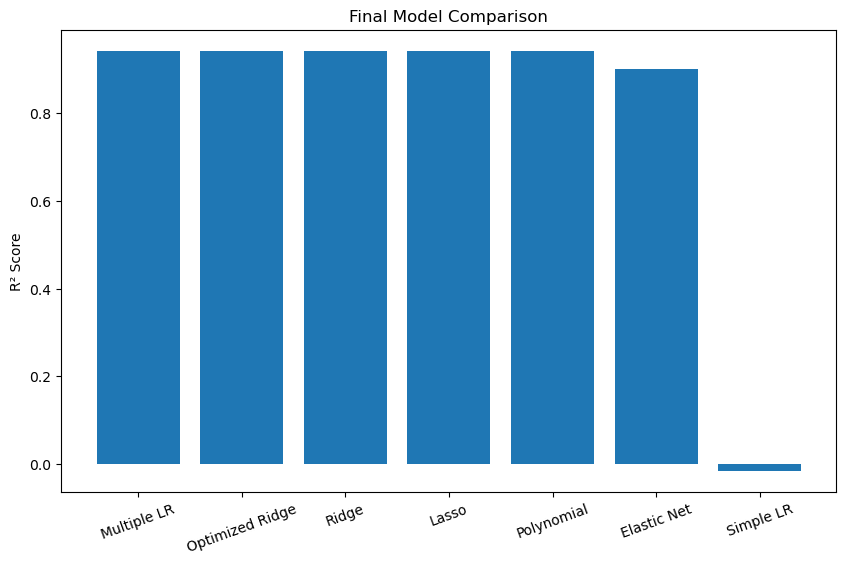

In [74]:
plt.figure(figsize=(10,6))

plt.bar(

    final_results["Model"],

    final_results["R2"]

)

plt.xticks(rotation=20)

plt.ylabel("R² Score")

plt.title("Final Model Comparison")

plt.show()

In [ ]:
# ============================================================
# Interactive House Price Prediction
# ============================================================

area = float(input("Enter Area (sqft): "))
bedrooms = int(input("Enter Bedrooms: "))
bathrooms = int(input("Enter Bathrooms: "))
house_age = int(input("Enter House Age: "))
distance = float(input("Distance from City (km): "))
parking = int(input("Parking Spaces: "))
quality = int(input("Quality Score (1-10): "))
crime = float(input("Crime Rate: "))
school = int(input("School Rating (1-10): "))

new_house = pd.DataFrame({

    "Area":[area],
    "Bedrooms":[bedrooms],
    "Bathrooms":[bathrooms],
    "HouseAge":[house_age],
    "DistanceCity":[distance],
    "Parking":[parking],
    "Quality":[quality],
    "CrimeRate":[crime],
    "SchoolRating":[school],
    "AreaPerBedroom":[area/bedrooms],
    "OldHouse":[1 if house_age > 20 else 0],
    "QualitySchool":[quality*school]

})

new_house_scaled = scaler.transform(new_house)

prediction = best_ridge.predict(new_house_scaled)

print("\n🏠 Estimated House Price")
print(f"₹ {prediction[0]:,.2f}")